2025-12-29 14-12-12
Outputs will be written to: results/run_2025-12-29 14-12-12
Saved a copy of the config : results/run_2025-12-29 14-12-12/config_copy.yaml
Inputs shape: (29, 4)
Outputs shape: (29,)
First 20 rows of raw data:
       var-1     var-2     var-3     var-4        yield  source
28  0.803000  0.790000  1.070000  1.140000  7705.825094  week-9
26  0.353188  0.520322  1.112618  1.186113  6717.039991  week-7
25  0.797599  0.775484  1.047075  1.122867  6619.923796  week-6
24  0.263058  0.962540  0.979484  1.057644  4564.328857  week-5
27  0.287950  0.950000  0.950000  1.050000  3942.207447  week-8
22  0.272727  0.848484  0.848485  0.818182  1118.872547  week-3
15  0.224189  0.846480  0.879484  0.878516  1088.859618    file
20  0.183674  0.857143  0.816327  0.877551   872.307487  week-1
21  0.272727  0.848484  0.848485  0.818182   743.118248  week-2
18  0.119879  0.862540  0.643331  0.849804   431.612757    file
23  0.242085  0.848724  0.469207  0.893286   386.681874  week-4
14  

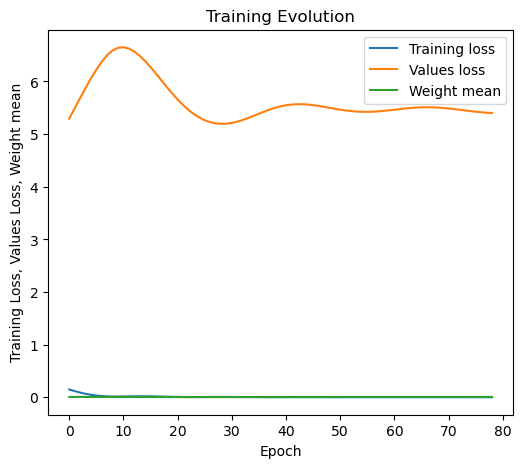

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (2000, 4)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 2
{'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.11261395, 0.02511109, 0.56746879, 1.14482726]), 'score': 7.837615966193192e-07, 'dim': 4, 'predicted_y': 444.85284}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.11261395, 0.02511109, 0.56746879, 1.14482726]), 'score': 7.340715975097407e-07, 'dim': 4, 'predicted_y': 444.85284}
🔍 Best candidate (highest acquisition score):
Method: EI
xi: 0.0
Dimensions: 4
x: [0.112614, 0.025111, 0.567469, 1.144827]
Score: 0.000001
Base dataframe built with shape: (29, 6)

=== Results for grid_size=2000 ===


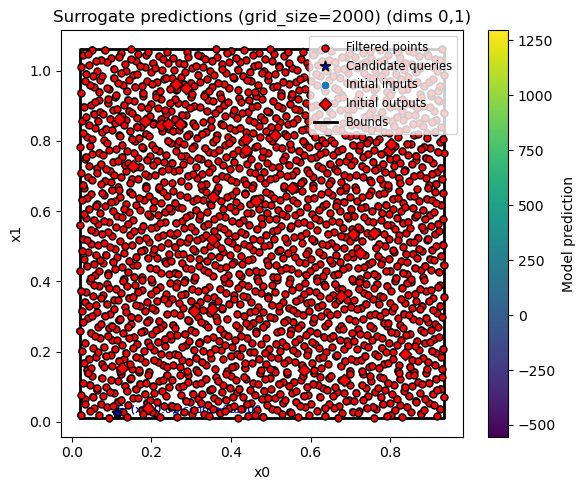

Saved dataframe to: results/run_2025-12-29 14-12-12/df_grid_2000_stride4_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'EI', 'xi': 0.0, 'kappa': None, 'x': array([0.11261395, 0.02511109, 0.56746879, 1.14482726]), 'score': 7.837615966193192e-07, 'dim': 4, 'predicted_y': 444.85284}
       var-1     var-2     var-3     var-4         yield  source  yield-scaled
0   0.803000  0.790000  1.070000  1.140000  7.705825e+03  week-9  1.000000e+01
1   0.353188  0.520322  1.112618  1.186113  6.717040e+03  week-7  8.716834e+00
2   0.797599  0.775484  1.047075  1.122867  6.619924e+03  week-6  8.590805e+00
3   0.263058  0.962540  0.979484  1.057644  4.564329e+03  week-5  5.923219e+00
4   0.287950  0.950000  0.950000  1.050000  3.942207e+03  week-8  5.115880e+00
5   0.272727  0.848484  0.848485  0.818182  1.118873e+03  week-3  1.451983e+00
6   0.224189  0.846480  0.879484  0.878516  1.088860e+03    file  1.413034e+00
7   0.183674  0.857143  0.816327  0.877551  8.723075e+02  week-1  1.132010e

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))